In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Topic and Problem Statement
### Topic:    Comparative Analysis of Stock Volatility: Microsoft, Apple, and Tesla

### Problem Statement:
Investors often want to understand which stocks are stable and which are volatile, as stability affects investment risk and decision-making. This study examines the daily price movements, returns, and volatility of three major tech companies: Microsoft, Apple, and Tesla. The goal is to identify how stable Microsoft and Apple are compared to Tesla and explore why Tesla exhibits higher volatility. This analysis can help investors and analysts make informed decisions regarding risk exposure and portfolio allocation.

## 1. Pre-Processesing of Data

In [4]:
df = pd.read_csv('/Users/srisuphachawla/Documents/DataScienceNotes/Datasets/stock_market_data.csv', header = [0,1])
df

Price       Close                                High              \
          Ticker        AAPL        MSFT        TSLA        AAPL        MSFT   
0           Date         NaN         NaN         NaN         NaN         NaN   
1     2018-01-02   40.341885   79.050354   21.368668   40.351254   79.381456   
2     2018-01-03   40.334866   79.418282   21.150000   40.878192   79.565441   
3     2018-01-04   40.522221   80.117271   20.974667   40.625266   80.623123   
4     2018-01-05   40.983578   81.110565   21.105333   41.070228   81.312906   
...          ...         ...         ...         ...         ...         ...   
2032  2026-02-02  270.010010  423.369995  421.809998  270.489990  430.739990   
2033  2026-02-03  269.480011  411.209991  421.959991  271.880005  422.049988   
2034  2026-02-04  276.489990  414.190002  406.010010  278.950012  419.799988   
2035  2026-02-05  275.910004  393.670013  397.209991  279.500000  408.299988   
2036  2026-02-06  278.119995  401.140015  411.109985  280.910004  401.790009   

                         Low                                Open              \
            TSLA        AAPL        MSFT        TSLA        AAPL        MSFT   
0            NaN         NaN         NaN         NaN         NaN         NaN   
1      21.474001   39.639309   78.636481   20.733334   39.850084   79.215905   
2      21.683332   40.271636   79.068788   21.036667   40.405124   79.151560   
3      21.236668   40.299739   79.620619   20.378668   40.407465   79.639010   
4      21.149332   40.526904   80.411572   20.799999   40.618239   80.623112   
...          ...         ...         ...         ...         ...         ...   
2032  427.149994  259.209991  422.250000  414.500000  260.029999  430.239990   
2033  428.559998  267.609985  408.559998  413.690002  269.200012  422.010010   
2034  423.899994  272.290009  409.239990  399.179993  272.290009  411.000000   
2035  402.100006  273.230011  392.320007  387.529999  278.130005  407.440002   
2036  414.549988  276.929993  392.920013  397.750000  277.119995  399.170013   

                       Volume                           
            TSLA         AAPL        MSFT         TSLA  
0            NaN          NaN         NaN          NaN  
1      20.799999  102223600.0  22483800.0   65283000.0  
2      21.400000  118071600.0  26061400.0   67822500.0  
3      20.858000   89738400.0  21912000.0  149194500.0  
4      21.108000   94640000.0  23407100.0   68868000.0  
...          ...          ...         ...          ...  
2032  421.290009   73913400.0  42219900.0   58739500.0  
2033  424.269989   64394700.0  61424100.0   56886500.0  
2034  420.459991   90545700.0  45012400.0   74606900.0  
2035  397.019989   52977400.0  66289200.0   72819800.0  
2036  400.869995   50420700.0  53403600.0   62559600.0  

[2037 rows x 16 columns]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2037 entries, 0 to 2036
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Price, Ticker)  2037 non-null   object 
 1   (Close, AAPL)    2036 non-null   float64
 2   (Close, MSFT)    2036 non-null   float64
 3   (Close, TSLA)    2036 non-null   float64
 4   (High, AAPL)     2036 non-null   float64
 5   (High, MSFT)     2036 non-null   float64
 6   (High, TSLA)     2036 non-null   float64
 7   (Low, AAPL)      2036 non-null   float64
 8   (Low, MSFT)      2036 non-null   float64
 9   (Low, TSLA)      2036 non-null   float64
 10  (Open, AAPL)     2036 non-null   float64
 11  (Open, MSFT)     2036 non-null   float64
 12  (Open, TSLA)     2036 non-null   float64
 13  (Volume, AAPL)   2036 non-null   float64
 14  (Volume, MSFT)   2036 non-null   float64
 15  (Volume, TSLA)   2036 non-null   float64
dtypes: float64(15), object(1)
memory usage: 254.8+ KB


In [6]:
# removing the faux date row
df = df.iloc[1:].copy()

In [7]:
# flattening columns temporarily for an easier reshape
df.columns = [
    f'{col[0]}_{col[1]}' if col[1] != '' else col[0] for col in df.columns
]
df

,Price_Ticker,Close_AAPL,Close_MSFT,Close_TSLA,High_AAPL,High_MSFT,High_TSLA,Low_AAPL,Low_MSFT,Low_TSLA,Open_AAPL,Open_MSFT,Open_TSLA,Volume_AAPL,Volume_MSFT,Volume_TSLA
1,2018-01-02,40.341885,79.050354,21.368668,40.351254,79.381456,21.474001,39.639309,78.636481,20.733334,39.850084,79.215905,20.799999,102223600.0,22483800.0,65283000.0
2,2018-01-03,40.334866,79.418282,21.150000,40.878192,79.565441,21.683332,40.271636,79.068788,21.036667,40.405124,79.151560,21.400000,118071600.0,26061400.0,67822500.0
3,2018-01-04,40.522221,80.117271,20.974667,40.625266,80.623123,21.236668,40.299739,79.620619,20.378668,40.407465,79.639010,20.858000,89738400.0,21912000.0,149194500.0
4,2018-01-05,40.983578,81.110565,21.105333,41.070228,81.312906,21.149332,40.526904,80.411572,20.799999,40.618239,80.623112,21.108000,94640000.0,23407100.0,68868000.0
5,2018-01-08,40.831341,81.193336,22.427334,41.126421,81.469257,22.468000,40.732977,80.567923,21.033333,40.831341,81.119757,21.066668,82271200.0,22113000.0,147891000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2032,2026-02-02,270.010010,423.369995,421.809998,270.489990,430.739990,427.149994,259.209991,422.250000,414.500000,260.029999,430.239990,421.290009,73913400.0,42219900.0,58739500.0
2033,2026-02-03,269.480011,411.209991,421.959991,271.880005,422.049988,428.559998,267.609985,408.559998,413.690002,269.200012,422.010010,424.269989,64394700.0,61424100.0,56886500.0
2034,2026-02-04,276.489990,414.190002,406.010010,278.950012,419.799988,423.899994,272.290009,409.239990,399.179993,272.290009,411.000000,420.459991,90545700.0,45012400.0,74606900.0
2035,2026-02-05,275.910004,393.670013,397.209991,279.500000,408.299988,402.100006,273.230011,392.320007,387.529999,278.130005,407.440002,397.019989,52977400.0,66289200.0,72819800.0


In [31]:
# melt and organize
df_long = df.melt(
    id_vars = ['Price_Ticker'],
    var_name = 'Feature_Ticker',
    value_name = 'Value'
)
df_long[['Feature', 'Ticker']] = df_long['Feature_Ticker'].str.split('_', expand = True)

df_final = df_long.pivot_table(
    index = ['Price_Ticker', 'Ticker'],
    columns = 'Feature',    
    values = 'Value'
).reset_index()

# Convertion to DateTime
df_final['Price_Ticker'] = pd.to_datetime(df_final['Price_Ticker'])
df_final.to_csv('stock_data_clean.csv', index=False)
df_final


Feature,Price_Ticker,Ticker,Close,High,Low,Open,Volume
0,2018-01-02,AAPL,40.341885,40.351254,39.639309,39.850084,102223600.0
1,2018-01-02,MSFT,79.050354,79.381456,78.636481,79.215905,22483800.0
2,2018-01-02,TSLA,21.368668,21.474001,20.733334,20.799999,65283000.0
3,2018-01-03,AAPL,40.334866,40.878192,40.271636,40.405124,118071600.0
4,2018-01-03,MSFT,79.418282,79.565441,79.068788,79.151560,26061400.0
...,...,...,...,...,...,...,...
6103,2026-02-05,MSFT,393.670013,408.299988,392.320007,407.440002,66289200.0
6104,2026-02-05,TSLA,397.209991,402.100006,387.529999,397.019989,72819800.0
6105,2026-02-06,AAPL,278.119995,280.910004,276.929993,277.119995,50420700.0
6106,2026-02-06,MSFT,401.140015,401.790009,392.920013,399.170013,53403600.0


## 2. Dataset Overview


In [9]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6108 entries, 0 to 6107
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Price_Ticker  6108 non-null   datetime64[ns]
 1   Ticker        6108 non-null   object        
 2   Close         6108 non-null   float64       
 3   High          6108 non-null   float64       
 4   Low           6108 non-null   float64       
 5   Open          6108 non-null   float64       
 6   Volume        6108 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 334.2+ KB


In [10]:
df_final.describe()

Feature,Price_Ticker,Close,High,Low,Open,Volume
count,6108,6108.000000,6108.000000,6108.000000,6108.000000,6.108000e+03
mean,2022-01-17 17:02:00.235756288,196.482501,199.148652,193.641184,196.448584,8.168167e+07
min,2018-01-02 00:00:00,11.931333,12.445333,11.799333,12.073333,5.855900e+06
25%,2020-01-09 18:00:00,101.065298,102.224085,99.755783,101.053760,3.141062e+07
50%,2022-01-16 00:00:00,186.265907,188.476360,182.780993,185.890889,6.745025e+07
75%,2024-01-26 18:00:00,267.265007,270.795755,261.788229,267.010002,1.067669e+08
max,2026-02-06 00:00:00,541.057373,553.502444,539.759814,553.283183,9.140820e+08
std,NaN,123.548497,125.076232,121.986177,123.625906,6.746242e+07


In [11]:
# checking for duplicates

df_final.duplicated().sum()

np.int64(0)

## 3. Univariate analysis

In [12]:
# dividing into numerical and catgorical columns
numerical = df_final.select_dtypes(include=['float64']).columns
categorical = df_final.select_dtypes(include=['object']).columns

In [13]:
desc_stats = df_final[numerical].describe().T

desc_stats.round(2)

,count,mean,std,min,25%,50%,75%,max
Feature,,,,,,,,
Close,6108.0,196.48,123.55,11.93,101.07,186.27,2.672700e+02,5.410600e+02
High,6108.0,199.15,125.08,12.45,102.22,188.48,2.708000e+02,5.535000e+02
Low,6108.0,193.64,121.99,11.80,99.76,182.78,2.617900e+02,5.397600e+02
Open,6108.0,196.45,123.63,12.07,101.05,185.89,2.670100e+02,5.532800e+02
Volume,6108.0,81681672.07,67462420.18,5855900.00,31410625.00,67450250.00,1.067669e+08,9.140820e+08


In [14]:
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
desc_stats['skenewss'] = df_final[numerical].skew()
desc_stats['kurtosis'] = df_final[numerical].kurtosis()

desc_stats.round(2)

,count,mean,std,min,25%,50%,75%,max,range,IQR,skenewss,kurtosis
Feature,,,,,,,,,,,,
Close,6108.0,196.48,123.55,11.93,101.07,186.27,2.672700e+02,5.410600e+02,5.291300e+02,166.20,0.53,-0.32
High,6108.0,199.15,125.08,12.45,102.22,188.48,2.708000e+02,5.535000e+02,5.410600e+02,168.57,0.52,-0.35
Low,6108.0,193.64,121.99,11.80,99.76,182.78,2.617900e+02,5.397600e+02,5.279600e+02,162.03,0.55,-0.29
Open,6108.0,196.45,123.63,12.07,101.05,185.89,2.670100e+02,5.532800e+02,5.412100e+02,165.96,0.54,-0.31
Volume,6108.0,81681672.07,67462420.18,5855900.00,31410625.00,67450250.00,1.067669e+08,9.140820e+08,9.082261e+08,75356300.00,2.51,12.46


In [15]:
for col in numerical:
    print(f"\n{'=' * 60}")
    print(f"Variable: {col.upper()}")
    print(f"{'=' * 60}")

    print("\n📊 Measures of Central Tendency:")
    print(f"   Mean:     ${df_final[col].mean():.2f}" if col in ['total_bill', 'tip'] else f"   Mean:     {df_final[col].mean():.2f}")
    print(f"   Median:   ${df_final[col].median():.2f}" if col in ['total_bill', 'tip'] else f"   Median:   {df_final[col].median():.2f}")
    print(f"   Mode:     {df_final[col].mode().values[0]:.2f}")

    print("\n📏 Measures of Spread:")
    print(f"   Range:    {df_final[col].max() - df_final[col].min():.2f}")
    print(f"   IQR:      {df_final[col].quantile(0.75) - df_final[col].quantile(0.25):.2f}")
    print(f"   Std Dev:  {df_final[col].std():.2f}")
    print(f"   Variance: {df_final[col].var():.2f}")

    print("\n📈 Measures of Shape:")
    print(f"   Skewness: {df_final[col].skew():.2f}", end="")
    if df_final[col].skew() > 0.5:
        print(" (Right-skewed/Positively skewed)")
    elif df_final[col].skew() < -0.5:
        print(" (Left-skewed/Negatively skewed)")
    else:
        print(" (Approximately symmetric)")

    print(f"   Kurtosis: {df_final[col].kurtosis():.2f}", end="")
    if df_final[col].kurtosis() > 3:
        print(" (Heavy-tailed)")
    elif df_final[col].kurtosis() < 3:
        print(" (Light-tailed)")
    else:
        print(" (Normal-tailed)")


Variable: CLOSE

📊 Measures of Central Tendency:
   Mean:     196.48
   Median:   186.27
   Mode:     14.64

📏 Measures of Spread:
   Range:    529.13
   IQR:      166.20
   Std Dev:  123.55
   Variance: 15264.23

📈 Measures of Shape:
   Skewness: 0.53 (Right-skewed/Positively skewed)
   Kurtosis: -0.32 (Light-tailed)

Variable: HIGH

📊 Measures of Central Tendency:
   Mean:     199.15
   Median:   188.48
   Mode:     20.31

📏 Measures of Spread:
   Range:    541.06
   IQR:      168.57
   Std Dev:  125.08
   Variance: 15644.06

📈 Measures of Shape:
   Skewness: 0.52 (Right-skewed/Positively skewed)
   Kurtosis: -0.35 (Light-tailed)

Variable: LOW

📊 Measures of Central Tendency:
   Mean:     193.64
   Median:   182.78
   Mode:     18.70

📏 Measures of Spread:
   Range:    527.96
   IQR:      162.03
   Std Dev:  121.99
   Variance: 14880.63

📈 Measures of Shape:
   Skewness: 0.55 (Right-skewed/Positively skewed)
   Kurtosis: -0.29 (Light-tailed)

Variable: OPEN

📊 Measures of Central T

## 4. Distribution Analysis

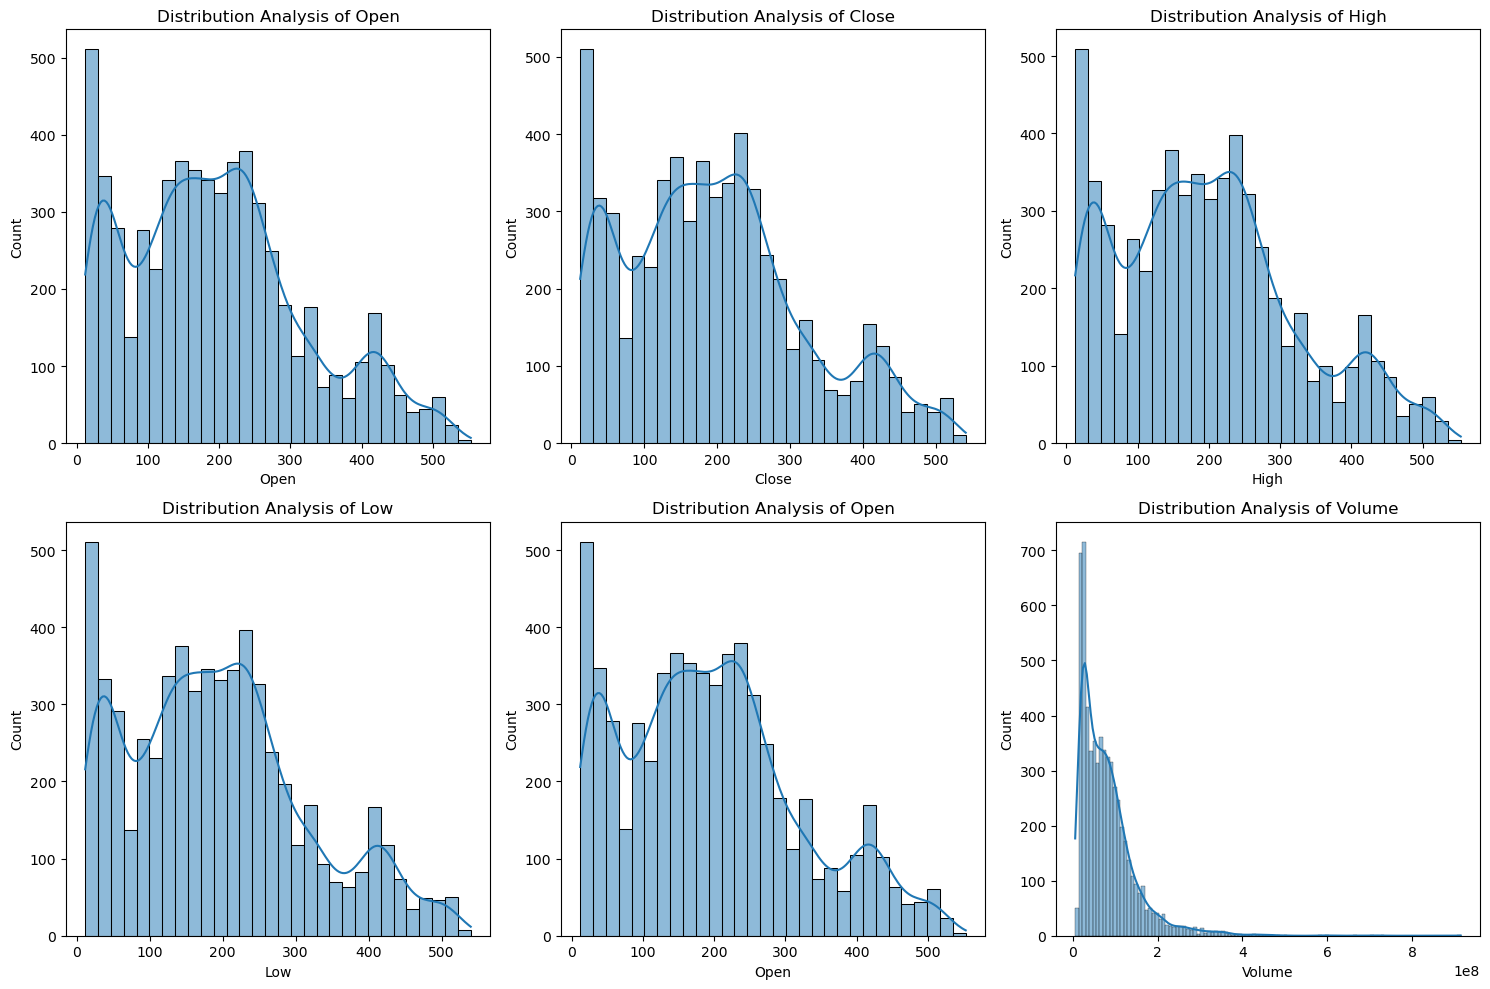

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

cols = ['Open', 'Close', 'High', 'Low', 'Open',	'Volume']

for i, j in enumerate(cols):
    sns.histplot(df_final[j], kde = True, ax=axes[i])
    axes[i].set_title(f"Distribution Analysis of {j}")

plt.tight_layout()
plt.show()


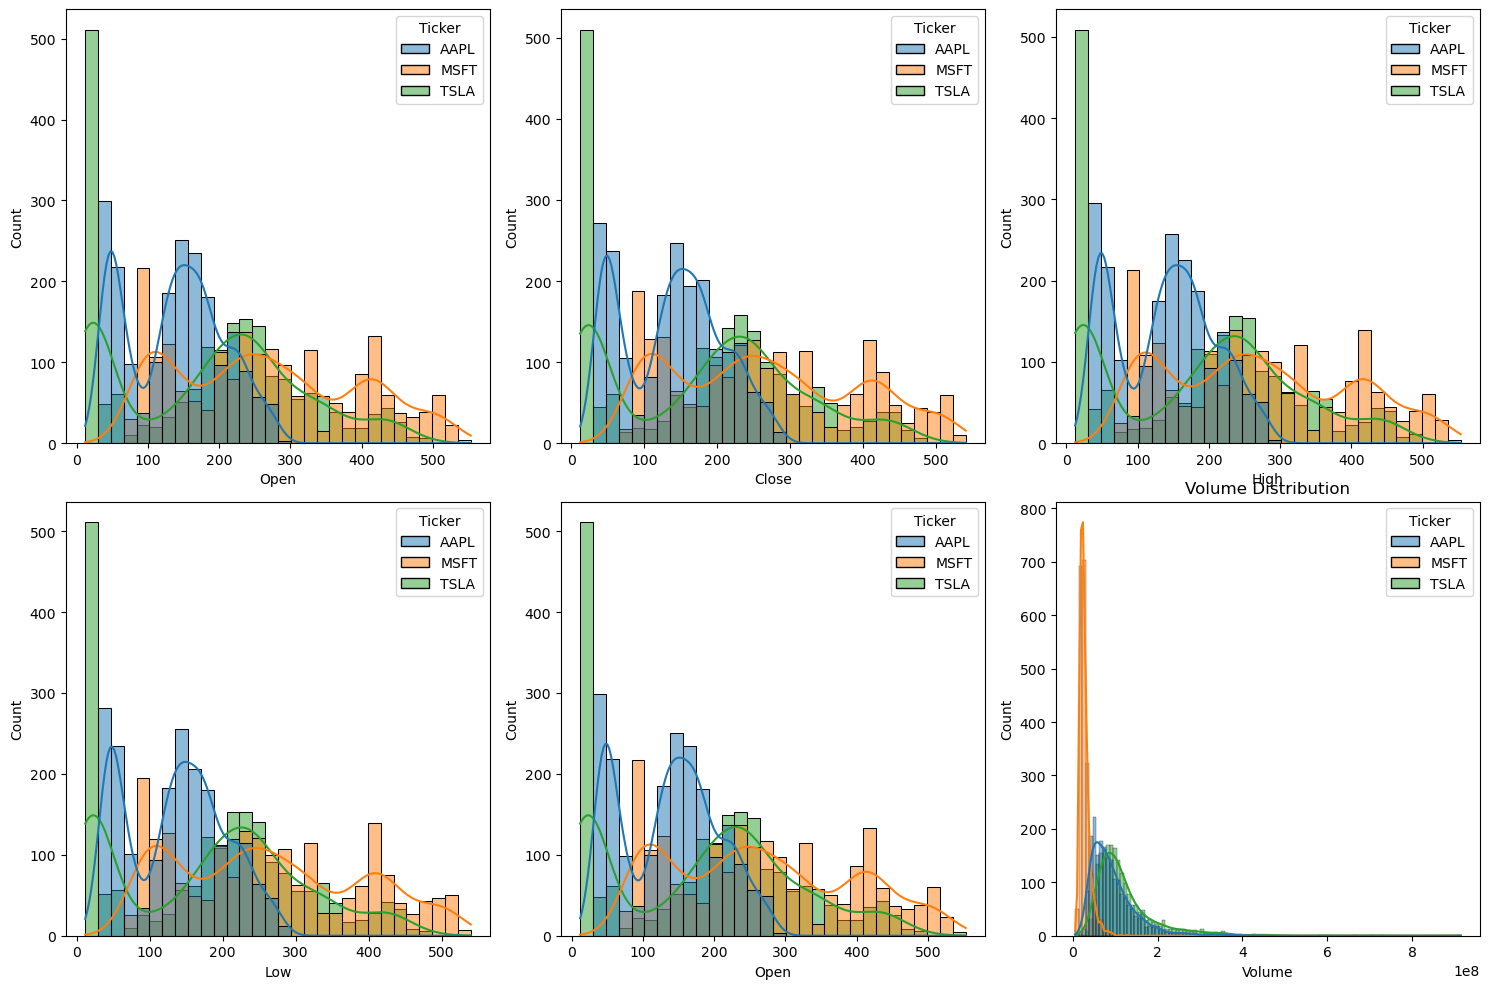

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, j in enumerate(cols):
    sns.histplot(data= df_final, x=j, hue = 'Ticker', kde = True, ax = axes[i])

plt.tight_layout()
plt.title("Volume Distribution")
plt.show()


### Interpretation of Distribution Analysis

The distribution of stock prices (Open, High, Low, Close) is approximately symmetric with slight positive skewness (~0.5) and low kurtosis (~-0.3), indicating relatively stable and well-distributed price movements with limited extreme outliers. 

In contrast, trading volume exhibits high positive skewness (2.51) and extremely high kurtosis (12.46), suggesting the presence of significant outliers and occasional spikes in trading activity. This indicates that while prices remain relatively stable, trading volume is highly irregular and driven by specific market events, contributing to periods of increased volatility, particularly in stocks like Tesla.



## 5. Outlier Detection

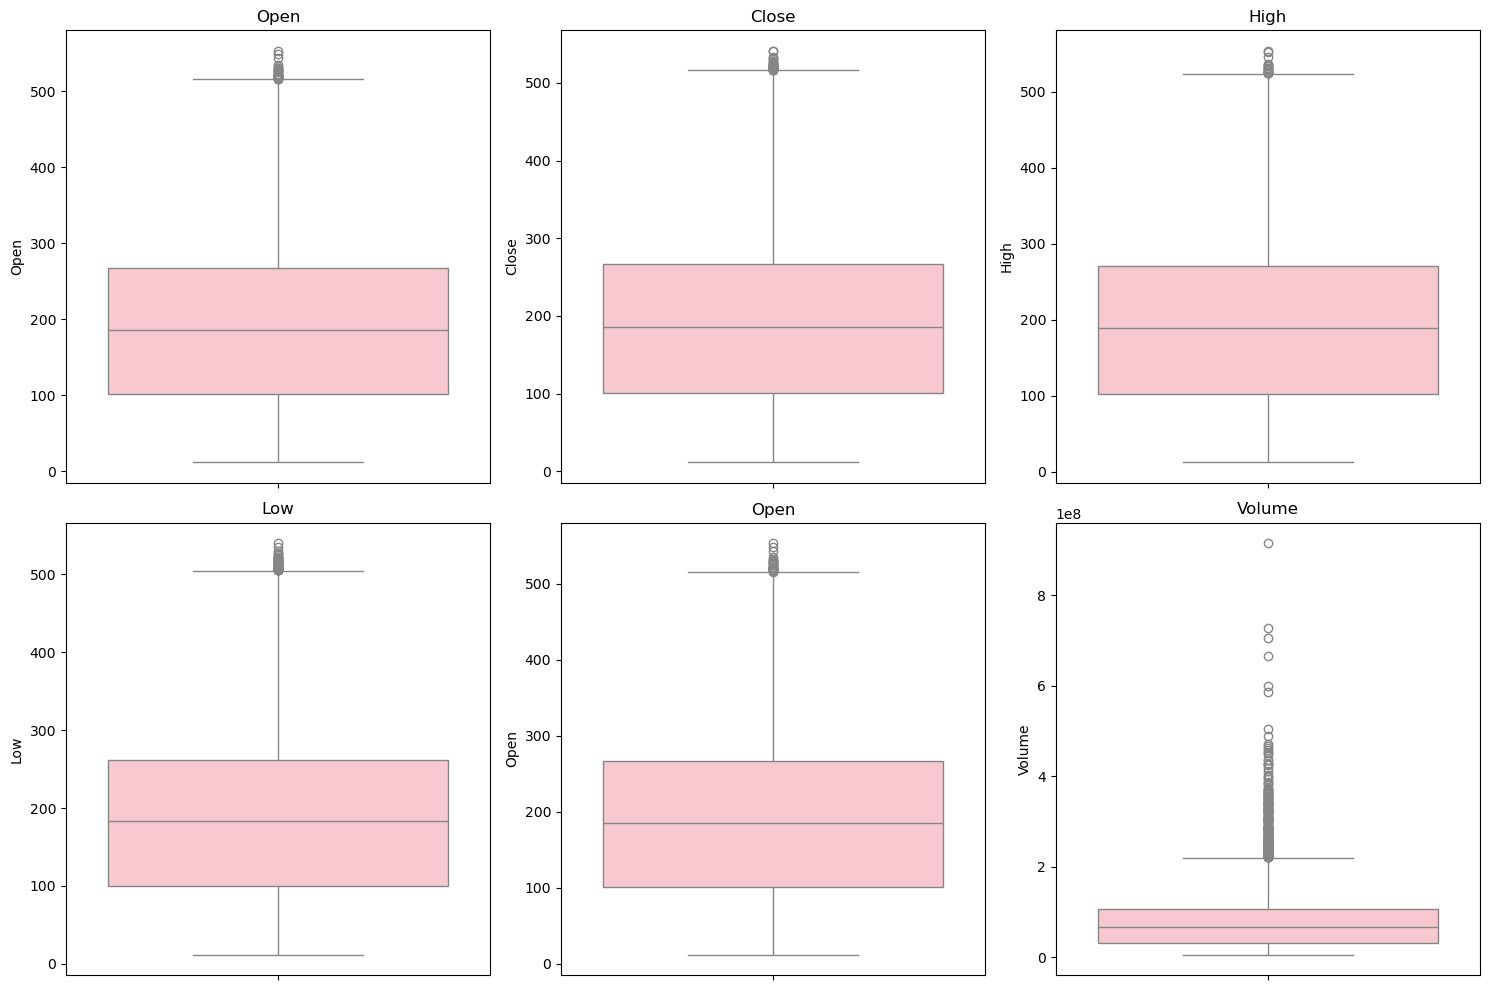

In [18]:

fig, axes = plt.subplots(2, 3, figsize = (15, 10))
axes_flat = axes.flatten()

for i, j in enumerate(cols):
    axes = axes_flat[i]

    sns.boxplot(data=df_final, y=j, ax= axes, color = 'pink')
    axes.set_title(j.title())

    Q1 = df_final[j].quantile(0.25)
    Q3 = df_final[j].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_final[(df_final[j] < lower_bound) | (df_final[j] > upper_bound)]


plt.tight_layout()
plt.show()                   

### Interpretation

Outlier detection was performed on all components to identify unusual or extreme values. The results show that price-related variables (Open, High, Low, Close) have relatively few outliers, indicating stable price movements over time. 

In contrast, trading volume and daily returns contain several extreme values, reflecting sudden spikes in market activity and large price changes. These outliers are not errors but represent real market events and are especially noticeable in stocks like Tesla, contributing to its higher volatility.

## 6. Time Series Analysis

In [19]:
df_final = df_final.sort_values(by = ['Ticker', 'Price_Ticker'])

# separating the dataset by each stock, focusing on the closing price, and for each stock, take a window of 30 days and compute the average closing price
df_final['MA_30'] = df_final.groupby('Ticker')['Close'].transform(lambda x : x.rolling(30).mean())
df_final['MA_100'] = df_final.groupby('Ticker')['Close'].transform(lambda x : x.rolling(100).mean())
df_final['MA_1000'] = df_final.groupby('Ticker')['Close'].transform(lambda x : x.rolling(1000).mean())
df_final['Range'] = df_final['High'] - df_final['Low']

df_final['Daily_Return'] = df_final.groupby('Ticker')['Close'].pct_change()
df_final.to_csv("Final_Stock_Dataset.csv", index = False)

### Since the Nan values are only from moving averages, wwe can drop them 

In [20]:
df_final = df_final.dropna()

### Stock Price over Time

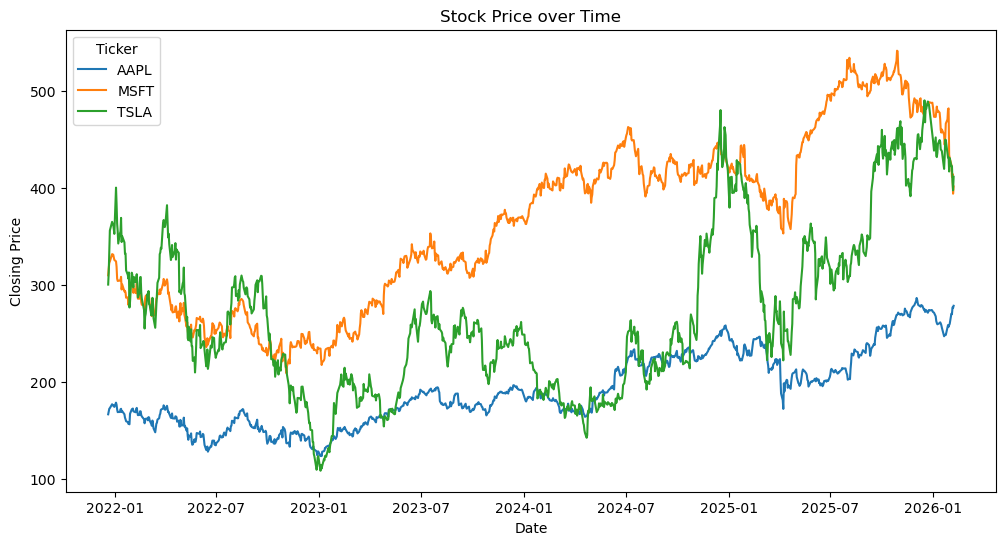

In [21]:
plt.figure(figsize = (12, 6))

sns.lineplot(data=df_final, x = 'Price_Ticker', y = 'Close', hue = 'Ticker')

plt.title("Stock Price over Time")
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

#### Interpretation:

Till Date, we can see that Tesla has been the most volatile stock out of all three stocks, with the most effective shock being the fall of the stock price from over $400 in 2022 to $100 in 2023, and then again, from $450 in 2024 end to $200 in 2025 beginning.

In relation, Microsoft and Apply stocks are more stable and have a steadier growth level from 2018 to 2026

### Moving Average: Trend Direction

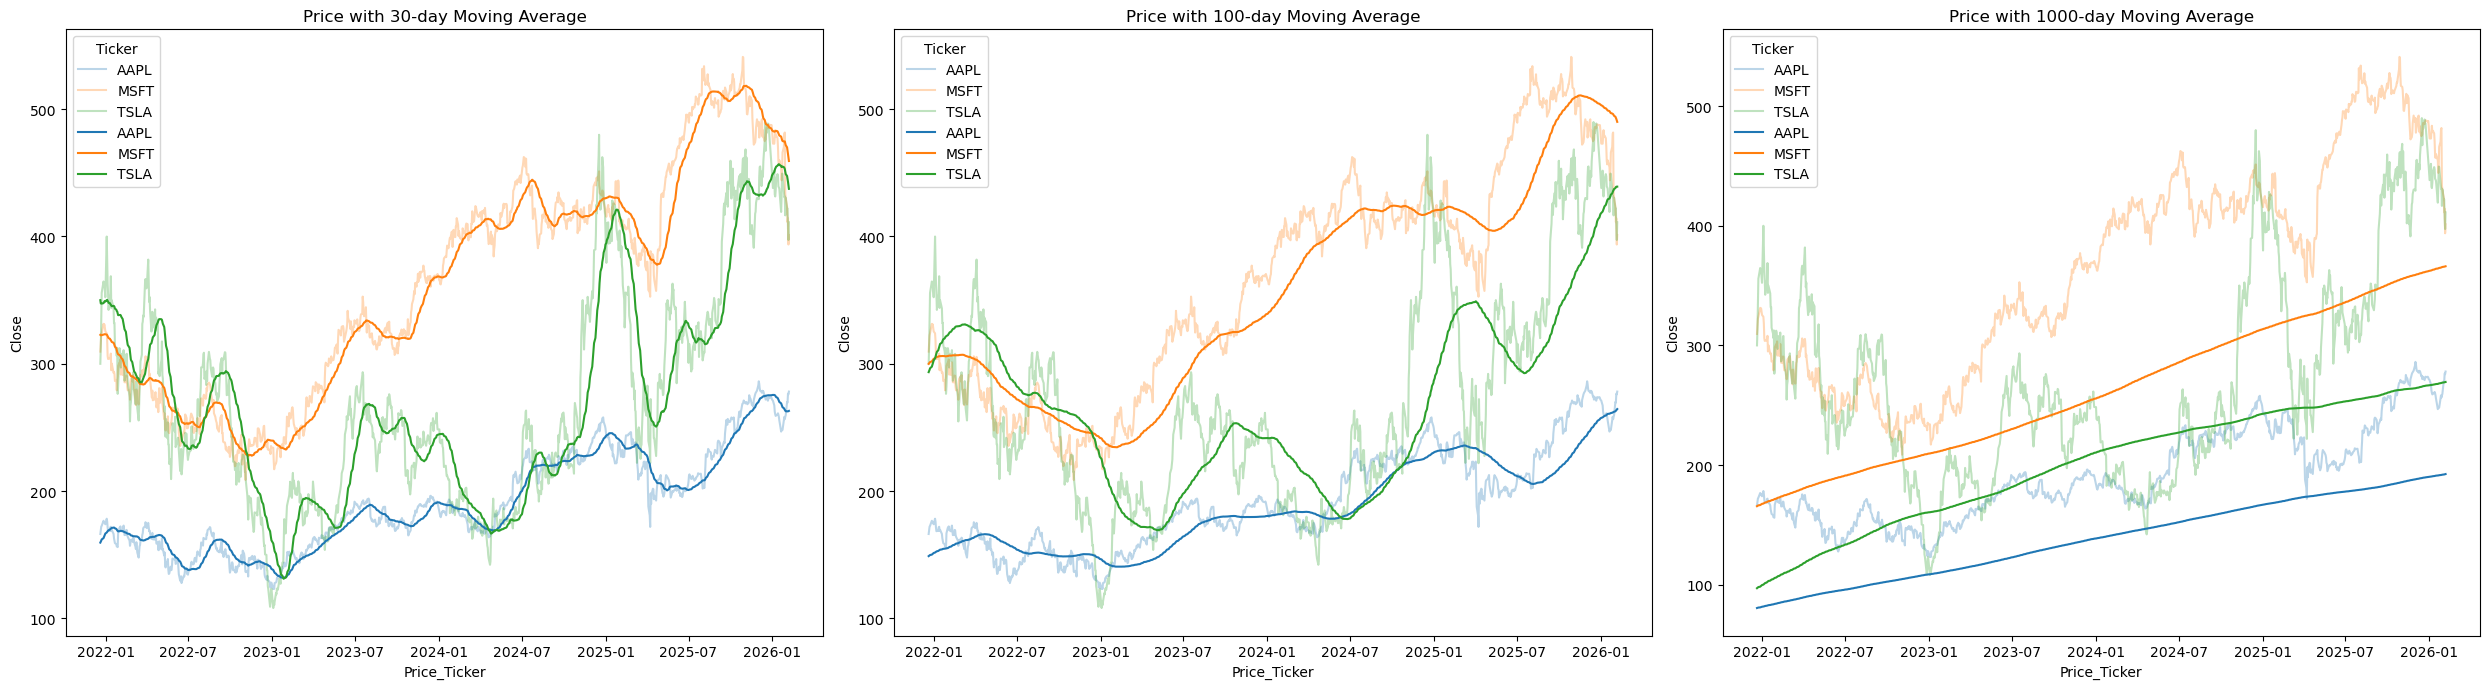

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(25, 7), sharex=True)

sns.lineplot(data = df_final, x = 'Price_Ticker', y = 'Close', hue = 'Ticker', alpha = 0.3, ax=axes[0])
sns.lineplot(data = df_final, x = 'Price_Ticker', y = 'MA_30', hue = 'Ticker', ax=axes[0])
axes[0].set_title("Price with 30-day Moving Average")


sns.lineplot(data = df_final, x = 'Price_Ticker', y = 'Close', hue = 'Ticker', alpha = 0.3, ax=axes[1])
sns.lineplot(data = df_final, x = 'Price_Ticker', y = 'MA_100', hue = 'Ticker', ax=axes[1])
axes[1].set_title("Price with 100-day Moving Average")

sns.lineplot(data = df_final, x = 'Price_Ticker', y = 'Close', hue = 'Ticker', alpha = 0.3, ax=axes[2])
sns.lineplot(data = df_final, x = 'Price_Ticker', y = 'MA_1000', hue = 'Ticker', ax=axes[2])
axes[2].set_title("Price with 1000-day Moving Average")

plt.tight_layout()
plt.show()


#### Interpretation 

An Exponential Moving Average is  a technical analysis indicator that measures trend direction over a period of time. 30-day, 100-day and 1000-day timeframes have been gvien above. The larger the number, the longer the term. Hence, 30-day checks for the shorter term and is closer to the overall stock price itself, while the 1000-day checks for the longer term trend

Typically, if the stock price line is above the give Moving Average, the price signals an upward trend and vice versa. 

Here, in the 1000-day Moving Average, for Apple and Microsoft, the stock price line stays above the EMA line, indicating that the price is in a constant upward trend. We can even point out that, for Apple, the price comes down just to touch the EMA line and bounces right back up (2023, mid-2024, and mid-2025). 

However, for Tesla, the stock price ends up going down and up, with a huge difference between the EMA line and the stock price, making it quite a volatile stock given the Exponential Moving Average



### Volume Over Time

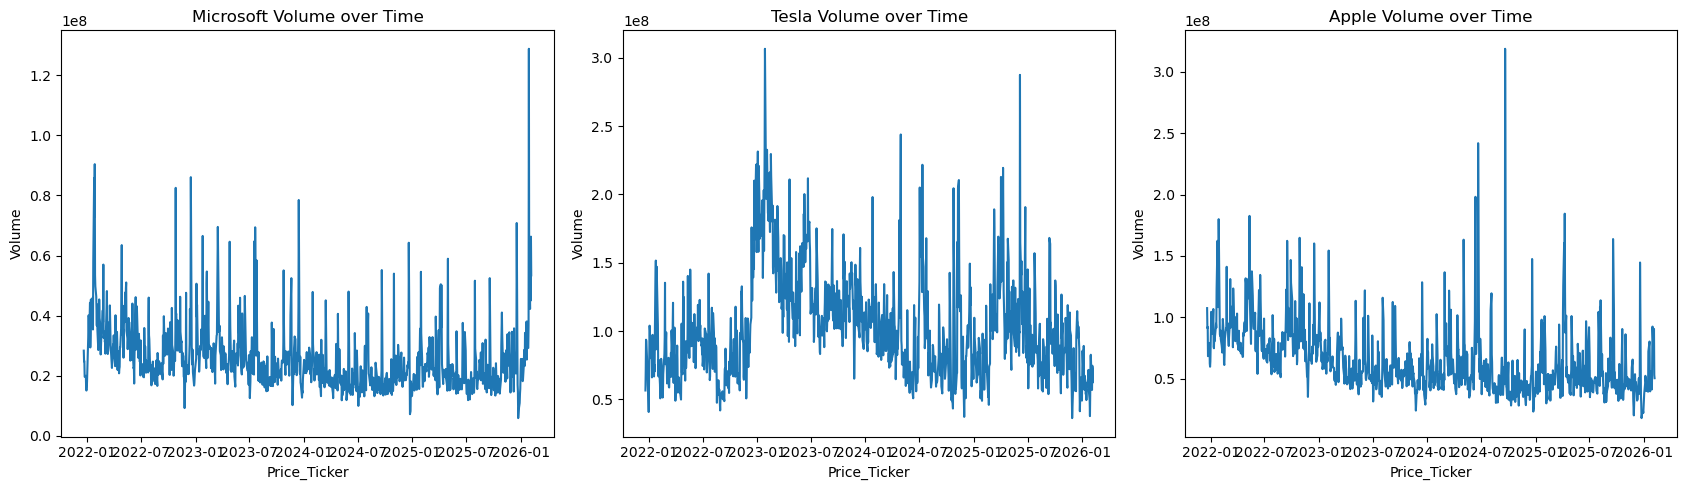

In [23]:
# Volume - How actively the stocks are being traded

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex =True)

sns.lineplot(data=df_final[df_final['Ticker'] == 'MSFT'], x='Price_Ticker', y='Volume', ax=axes[0])
axes[0].set_title("Microsoft Volume over Time")
axes[0].set_ylabel("Volume")

sns.lineplot(data=df_final[df_final['Ticker'] == 'TSLA'], x='Price_Ticker', y='Volume', ax=axes[1])
axes[1].set_title("Tesla Volume over Time")
axes[1].set_ylabel("Volume")

sns.lineplot(data=df_final[df_final['Ticker'] == 'AAPL'],  x='Price_Ticker', y='Volume', ax=axes[2])
axes[2].set_title("Apple Volume over Time")
axes[2].set_ylabel("Volume")
axes[2].set_xlabel("Price_Ticker")

plt.tight_layout()
plt.show()

### Interpretation

The volume over time chart shows how actively each stock is being traded. All three companies—Tesla, Microsoft, and Apple—display periods of rising and falling trading activity, indicating that market interest changes over time for all of them.

However, Microsoft stands out as having more consistent and similar patterns across the years. Its volume fluctuations are more regular and less extreme, suggesting steady investor interest and fewer sudden reactions to market events.

In contrast, Tesla and Apple show more irregular spikes and drops in volume. 

Where Volume is concerned, Microsoft is seemed to be the most stable



### Daily Returns

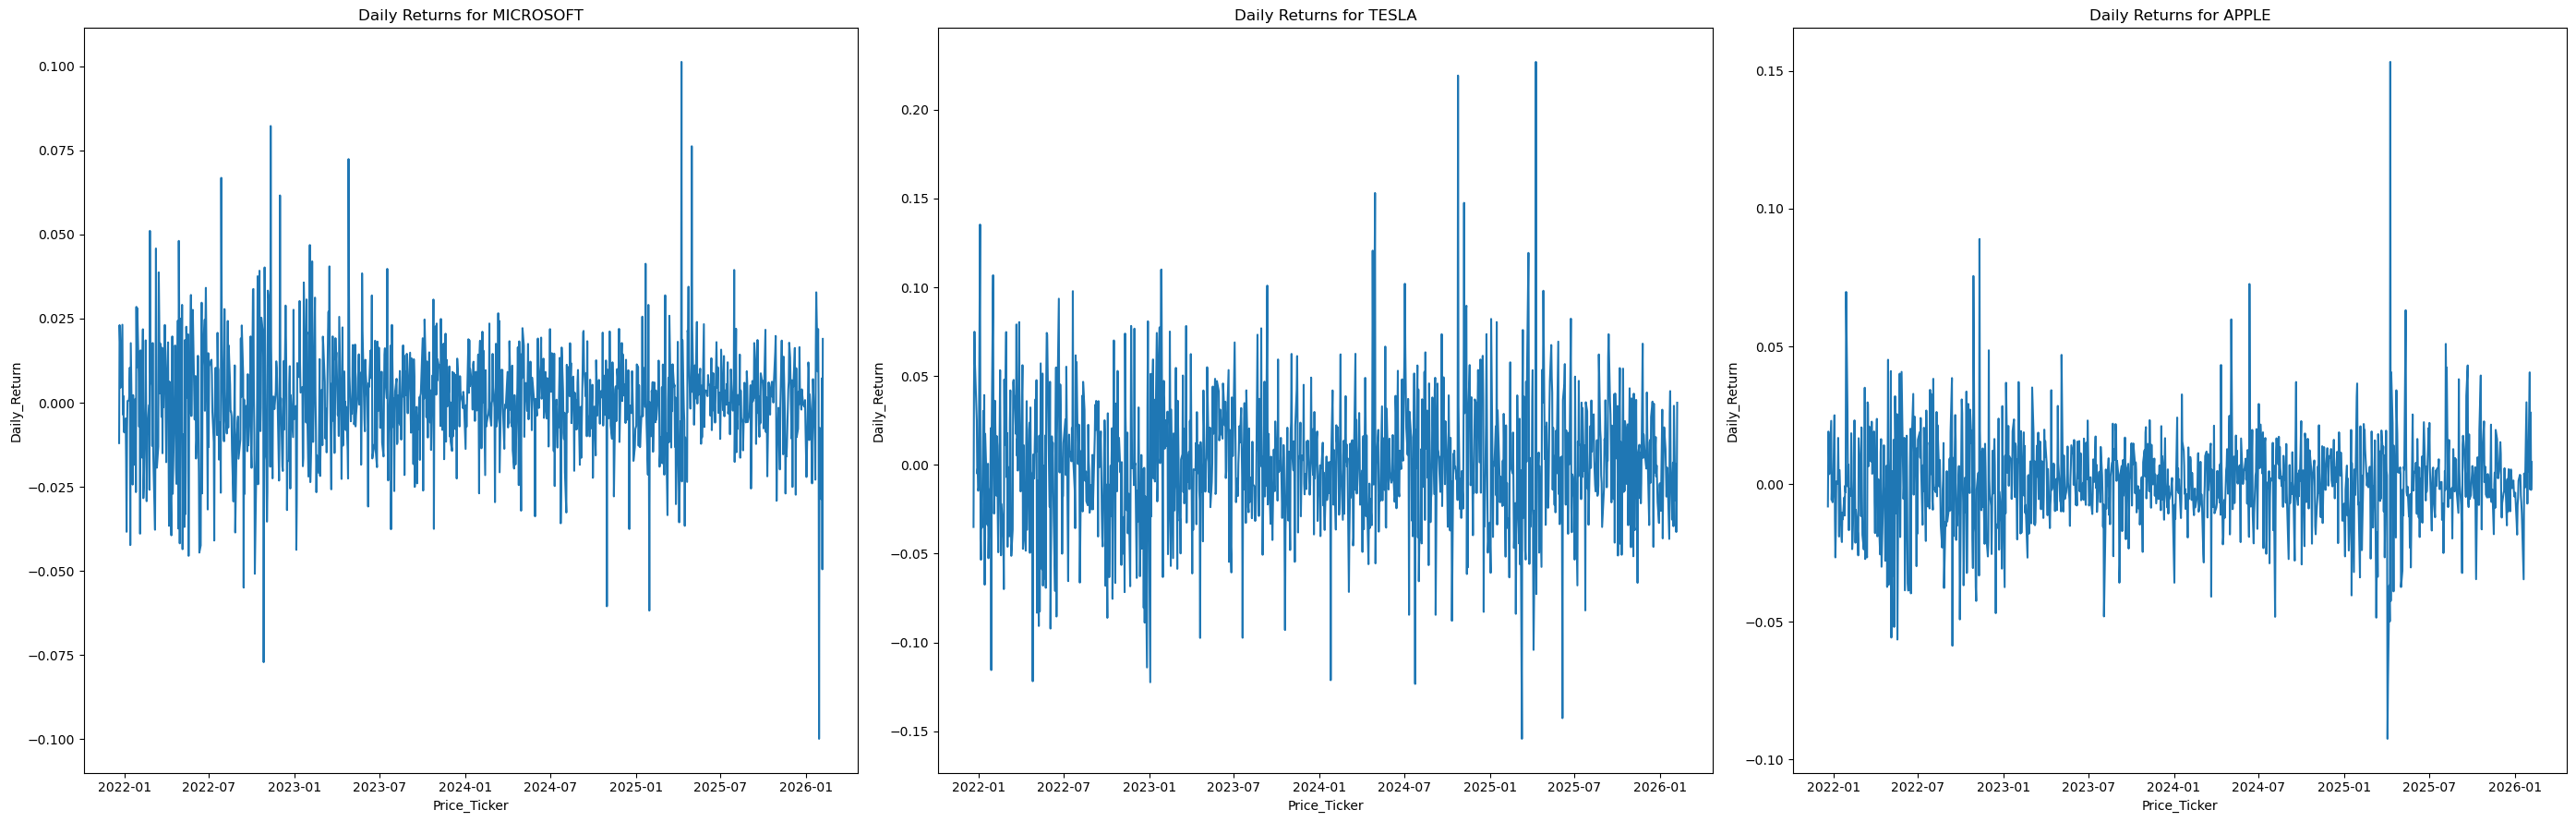

In [24]:
# How much each stock’s price changes from day to day.
figs, axes = plt.subplots(1, 3, figsize = (28, 9), sharex = True)

sns.lineplot(data=df_final[df_final['Ticker'] == 'MSFT'], x = 'Price_Ticker', y = 'Daily_Return', ax=axes[0])
axes[0].set_title("Daily Returns for MICROSOFT")

sns.lineplot(data=df_final[df_final['Ticker'] == 'TSLA'], x = 'Price_Ticker', y = 'Daily_Return', ax=axes[1])
axes[1].set_title("Daily Returns for TESLA")

sns.lineplot(data=df_final[df_final['Ticker'] == 'AAPL'], x = 'Price_Ticker', y = 'Daily_Return', ax=axes[2])
axes[2].set_title("Daily Returns for APPLE")

plt.tight_layout()
plt.show()

### Interpretation 
Overall, all three stocks fluctuate around zero, meaning that gains and losses are balanced over time. However, the magnitude and frequency of these fluctuations differ significantly.

Tesla clearly shows the highest volatility. Its chart has the largest spikes both upward and downward, indicating frequent and large price changes. There are multiple extreme movements (both positive and negative), showing that Tesla’s returns are more unpredictable and sensitive to market events.

Microsoft appears the most stable. Its returns are more tightly clustered around zero, with fewer and smaller spikes. This suggests more consistent performance and lower risk, as price changes are generally moderate and less extreme.

Apple lies in between. While it does show some spikes, they are less frequent and less extreme than Tesla’s, but slightly more noticeable than Microsoft’s. This indicates moderate volatility.

Another important observation is the presence of extreme spikes (outliers) in all three stocks, especially around certain periods (e.g., market shocks). However, these are much more pronounced in Tesla, reinforcing its higher risk profile.

## Volatility Analysis

### Standard deviation of daily returns

  Ticker  Std_Dev_Daily_Return
0   AAPL              0.017863
1   MSFT              0.017157
2   TSLA              0.038865


/var/folders/vg/vl7x2qd90x3fd40pxkwzq0tw0000gn/T/ipykernel_33885/174292498.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=volatility, x='Ticker', y='Std_Dev_Daily_Return', palette='Set2')


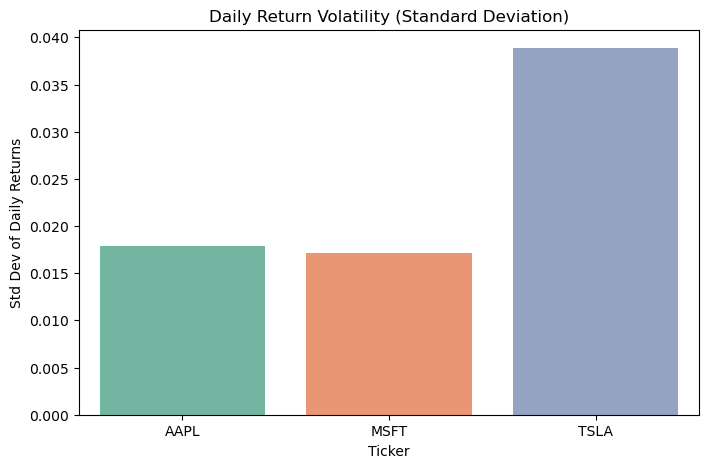

In [25]:
# Compute daily return std
volatility = df_final.groupby('Ticker')['Daily_Return'].std().reset_index()
volatility.rename(columns={'Daily_Return': 'Std_Dev_Daily_Return'}, inplace=True)
print(volatility)

# Bar chart
plt.figure(figsize=(8,5))
sns.barplot(data=volatility, x='Ticker', y='Std_Dev_Daily_Return', palette='Set2')
plt.title("Daily Return Volatility (Standard Deviation)")
plt.ylabel("Std Dev of Daily Returns")
plt.show()

### Interpretation

The table shows the standard deviation of daily returns, which measures how much each stock’s price changes from day to day. 

##### A higher value means the stock is more volatile, while a lower value means it is more stable.

Tesla has the highest standard deviation (~0.04), which means its daily returns vary the most. This confirms that Tesla is the most volatile stock, with large and frequent price swings.

Apple has a moderate standard deviation (0.019), indicating some variability but overall more stability compared to Tesla.

Microsoft has the lowest standard deviation (0.018), meaning its price changes are the most consistent and predictable. This makes it the most stable stock among the three.

### Rolling 30-day Volatility


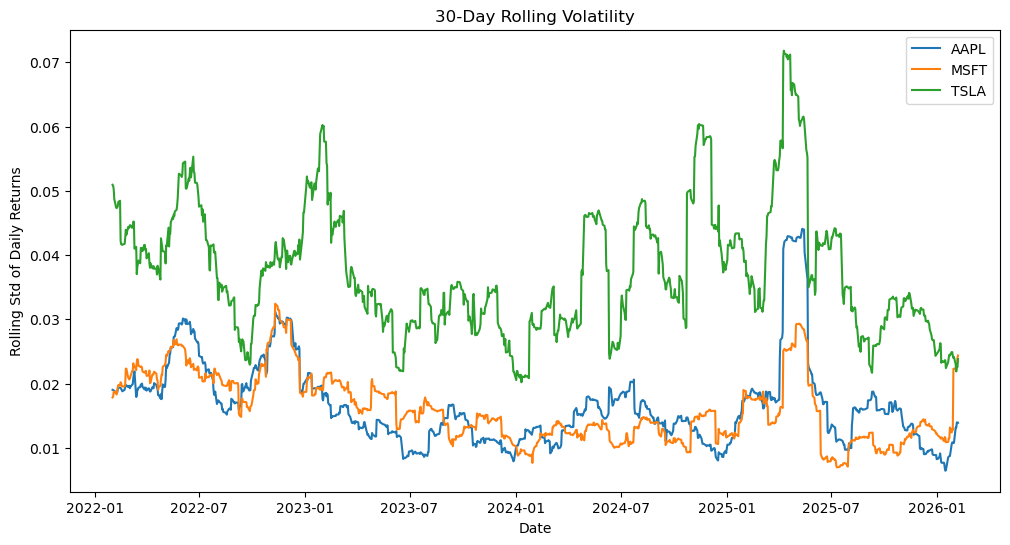

In [26]:
# Rolling 30-day Volatility - The average calculated over a moving window of time.

plt.figure(figsize=(12,6))

tickers = df_final['Ticker'].unique()
for ticker in tickers:
    rolling_vol = df_final[df_final['Ticker'] == ticker]['Daily_Return'].rolling(30).std()
    plt.plot(df_final[df_final['Ticker'] == ticker]['Price_Ticker'], rolling_vol, label=ticker)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Std of Daily Returns")
plt.legend()
plt.show()

### Interpretation 

The 30-day rolling volatility shows how the level of risk (price fluctuations) changes over time for each stock. Instead of giving one overall value, it helps us see when the market was more or less unstable.

Tesla consistently shows higher rolling volatility compared to the other stocks, with frequent spikes. This means Tesla experiences periods of intense price movement,

Apple shows moderate rolling volatility, with occasional increases during uncertain periods, but overall remains more stable than Tesla.

Microsoft has the lowest and most stable rolling volatility, with smoother and more consistent patterns over time. This indicates steady performance and lower risk.


### Average daily range (High-Low)

/var/folders/vg/vl7x2qd90x3fd40pxkwzq0tw0000gn/T/ipykernel_33885/726072712.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_range, x= 'Ticker', y='Range', palette='Set3', legend = False)


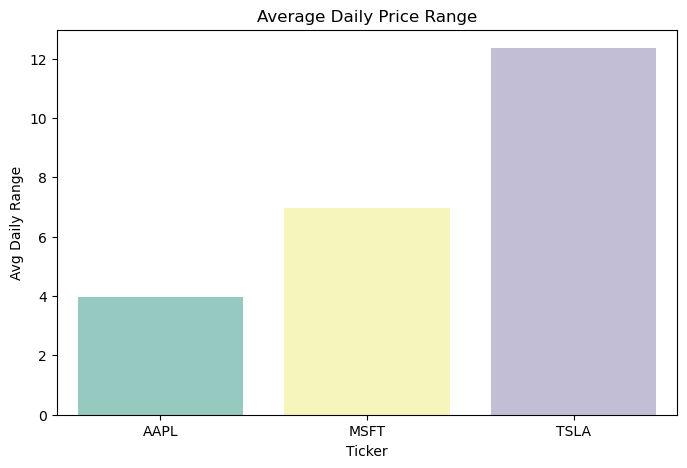

In [27]:
avg_range = df_final.groupby('Ticker')['Range'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=avg_range, x= 'Ticker', y='Range', palette='Set3', legend = False)
plt.title("Average Daily Price Range")
plt.ylabel("Avg Daily Range")
plt.show()

## Statistical Test and Machine Learning Model:

###  Spearman Correlation

In [28]:
# Remove missing and infinite values
clean_df = df_final[['Volume', 'Daily_Return']].replace([np.inf, -np.inf], np.nan).dropna()

corr, p_value = stats.spearmanr(clean_df['Volume'], clean_df['Daily_Return'])

n = len(clean_df)
z = np.arctanh(corr)
se = 1 / np.sqrt(n - 3)

z_crit = 1.96
z_lower = z - z_crit * se
z_upper = z + z_crit * se

r_lower = np.tanh(z_lower)
r_upper = np.tanh(z_upper)

print(f"Spearman r: {corr:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"95% CI: [{r_lower:.4f}, {r_upper:.4f}]")

Spearman r: 0.0109
p-value: 0.5452
95% CI: [-0.0243, 0.0460]


### Interpretation

The Spearman correlation coefficient (r = 0.0109) indicates an extremely weak relationship between trading volume and daily returns. The p-value (0.54) is greater than 0.05, showing that the result is not statistically significant. The confidence interval also includes zero, confirming that no meaningful relationship exists.

### Random Forest: 
chosen because it can detect both simple and complex patterns in the data. This makes it a strong method to test whether trading volume can predict returns, even if the relationship is not linear.

R² Score: -0.5514


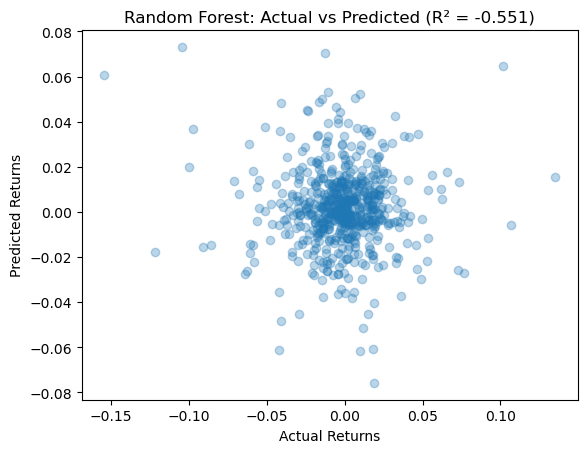

In [29]:
X = clean_df[['Volume']]
y = clean_df['Daily_Return']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)


r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

# Plotting actual vs predicted values
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title(f"Random Forest: Actual vs Predicted (R² = {r2:.3f})")
plt.show()

### Interpretation

#### R² measures how well your model predicts the data

The Random Forest model produced a negative R² score (-0.3835), indicating extremely poor predictive performance. This means trading volume not only fails to predict daily returns, but using it actually performs worse than a simple average-based prediction.

## Results and Discussion 

### **Stability vs Volatility**

The analysis of daily returns shows clear differences in stability among the stocks. Microsoft and Apple exhibit **low standard deviation and tightly clustered return distributions**, indicating stable and consistent price behavior.

In contrast, Tesla demonstrates a **significantly higher standard deviation, wider spread of returns, and more frequent outliers**, confirming that it is substantially more volatile.


### **Price Movement Trends**

The moving average analysis further supports these findings. Tesla’s price frequently **crosses its moving averages (MA30, MA50, MA100)**, reflecting rapid and frequent trend changes.

On the other hand, Microsoft and Apple show **smoother price movements that closely follow their moving averages**, indicating more predictable and stable trends over time.

### **Rolling Volatility**

The 30-day rolling volatility provides insight into how risk evolves over time. Tesla consistently shows **higher and more frequent spikes in volatility**, indicating periods of sudden and intense price fluctuations.

In comparison, Microsoft and Apple maintain **relatively low and stable rolling volatility**, with only occasional increases during broader market events.


### **Volume vs Price Movements**

Volume analysis reveals differences in investor behavior. Tesla’s **price movements often align with spikes in trading volume**, suggesting that its price is highly sensitive to news, speculation, and market sentiment.

Microsoft and Apple, however, display **more stable volume patterns**, with price changes that are less dependent on sudden increases in trading activity.

### **Statistical Test & Machine Learning Model**

Both statistical analysis and machine learning confirm that trading volume does not influence daily returns. The Spearman correlation shows no relationship, while the Random Forest model performs worse than a basic prediction model . This strongly suggests that trading volume is not a useful factor for predicting short-term stock price movements.

### **Conclusion**

Overall, Microsoft and Apple can be characterized as **stable, lower-risk stocks**, suitable for long-term investment strategies. In contrast, Tesla is a **highly volatile stock**, offering the potential for higher returns but also carrying significantly greater risk.

These findings highlight the importance of **diversification and risk management**, as investors must balance stability and growth when constructing a portfolio.


